## **Agglomerative Clustering**

### **Topic Roadmap**

**1. Load the original shopping dataset**

**2. Select clustering features**

**3. Inspect a linkage dendrogram**

**4. Fit agglomerative clustering**

**5. Key revision notes**

## **1. Dataset and Features**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

customers = pd.read_csv("docs/Lecture-097-shopping-data.csv")
X_raw = customers[["Annual Income (k$)", "Spending Score (1-100)"]]
X = StandardScaler().fit_transform(X_raw)
customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## **2. Linkage Dendrogram**

A dendrogram shows the order and distance at which observations or clusters are merged. Ward linkage minimizes the increase in within-cluster variance.

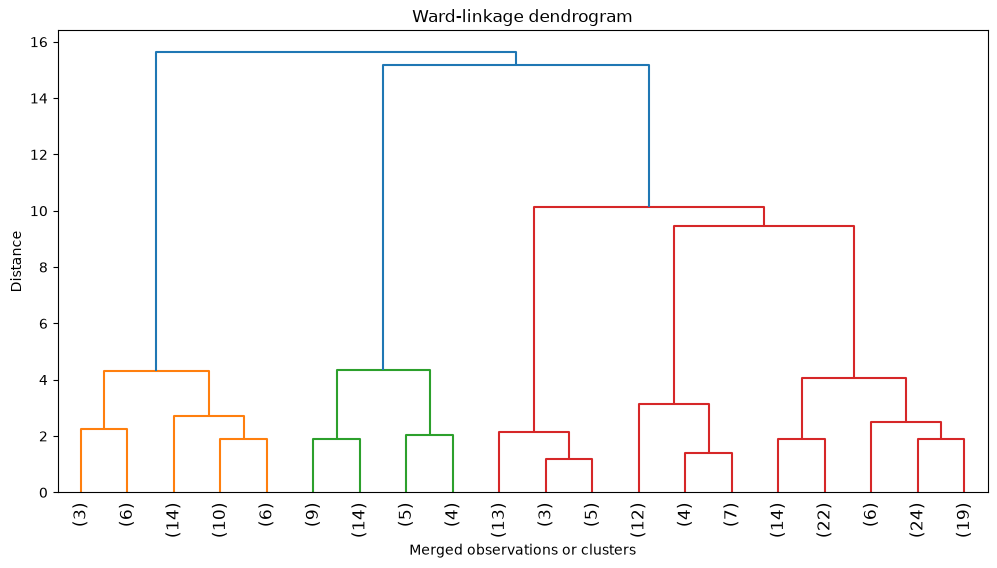

In [4]:
linkage_matrix = linkage(X, method="ward")
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=20, leaf_rotation=90)
plt.title("Ward-linkage dendrogram")
plt.xlabel("Merged observations or clusters")
plt.ylabel("Distance")
plt.show()

## **3. Fit Agglomerative Clustering**

Agglomerative clustering begins with one cluster per observation and repeatedly merges the closest pair. The current API uses `metric=`.

In [5]:
clusterer = AgglomerativeClustering(n_clusters=5, metric="euclidean", linkage="ward")
customers["cluster"] = clusterer.fit_predict(X)
print(customers["cluster"].value_counts().sort_index())

cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64


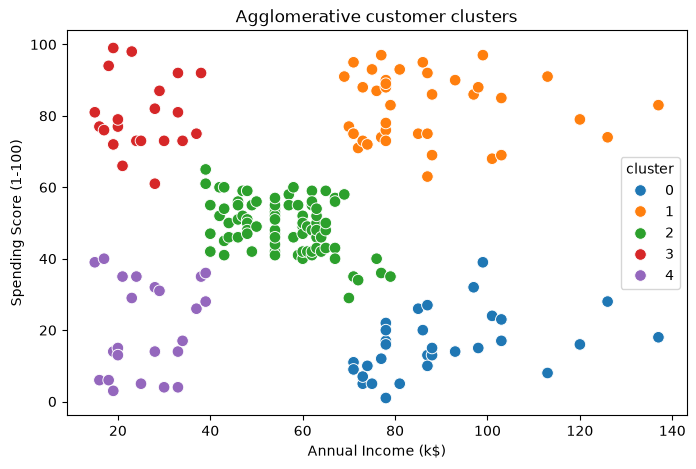

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=customers, x="Annual Income (k$)", y="Spending Score (1-100)", hue="cluster", palette="tab10", s=70)
plt.title("Agglomerative customer clusters")
plt.show()

### **Key Revision Notes**

- Agglomerative clustering is bottom-up hierarchical clustering.
- Linkage defines the distance between clusters.
- Ward linkage requires Euclidean distance and works with numeric features.
- Unlike K-Means, the algorithm does not require centroid initialization.